In [1]:
import sys
sys.path.append("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/src")

from player_analytics import *

In [2]:
import pandas as pd

In [3]:
match_id = 3869685

events = pd.read_json(
    f"C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/events/{match_id}.json"
)

events.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,duel,interception,dribble,shot,goalkeeper,ball_recovery,foul_committed,substitution,50_50,bad_behaviour
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,2026-06-22 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,2026-06-22 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,2026-06-22 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,2026-06-22 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,2026-06-22 00:00:00.578,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 771, 'name': 'France'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
passes = events[
    events['type'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ) == 'Pass'
]

print(passes.iloc[0]['pass'])

{'recipient': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'}, 'length': 13.364505, 'angle': 2.907503, 'height': {'id': 1, 'name': 'Ground Pass'}, 'end_location': [48.0, 43.2], 'type': {'id': 65, 'name': 'Kick Off'}, 'body_part': {'id': 38, 'name': 'Left Foot'}}


In [5]:
passes.iloc[0]['pass']

{'recipient': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'},
 'length': 13.364505,
 'angle': 2.907503,
 'height': {'id': 1, 'name': 'Ground Pass'},
 'end_location': [48.0, 43.2],
 'type': {'id': 65, 'name': 'Kick Off'},
 'body_part': {'id': 38, 'name': 'Left Foot'}}

In [6]:
import pandas as pd

def get_player_passes(events, player_name):

    passes = events[
        events['type'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == 'Pass'
    ]

    player_passes = passes[
        passes['player'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == player_name
    ]

    pass_data = []

    for _, row in player_passes.iterrows():

        pass_info = row['pass']

        pass_data.append({
            'x': row['location'][0],
            'y': row['location'][1],
            'end_x': pass_info['end_location'][0],
            'end_y': pass_info['end_location'][1],
            'successful': 'outcome' not in pass_info
        })

    return pd.DataFrame(pass_data)

In [7]:
messi_passes = get_player_passes(
    events,
    'Lionel Andrés Messi Cuccittini'
)

messi_passes.head()

,x,y,end_x,end_y,successful
0,76.6,35.7,116.2,8.9,True
1,99.3,57.3,96.7,49.8,True
2,67.9,59.0,49.0,60.3,True
3,81.8,65.2,70.2,67.7,True
4,39.2,48.1,65.3,35.4,True


In [8]:
def get_pass_accuracy(pass_df):

    total_passes = len(pass_df)

    successful_passes = pass_df['successful'].sum()

    accuracy = round(
        successful_passes / total_passes * 100,
        2
    )

    return accuracy

In [9]:
get_pass_accuracy(messi_passes)

np.float64(81.67)

In [10]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def plot_player_passmap(events, player_name):

    pass_df = get_player_passes(
        events,
        player_name
    )

    accuracy = get_pass_accuracy(pass_df)

    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color='#1B4332',
        line_color='white',
        linewidth=2
    )

    fig, ax = pitch.draw(figsize=(12, 8))

    successful = pass_df[
        pass_df['successful']
    ]

    unsuccessful = pass_df[
        ~pass_df['successful']
    ]

    # Successful passes
    pitch.arrows(
        successful['x'],
        successful['y'],
        successful['end_x'],
        successful['end_y'],
        color='#00ff88',
        width=1.5,
        ax=ax
    )

    # Failed passes
    pitch.arrows(
        unsuccessful['x'],
        unsuccessful['y'],
        unsuccessful['end_x'],
        unsuccessful['end_y'],
        color='#ff4d4d',
        width=1.5,
        ax=ax
    )

    fig.set_facecolor('#1B4332')

    ax.set_title(
        f"{player_name}\nPass Accuracy: {accuracy}%",
        color='white',
        fontsize=18
    )

    return fig

'🟢 Green arrows = successful passes\n🔴 Red arrows = failed passes'

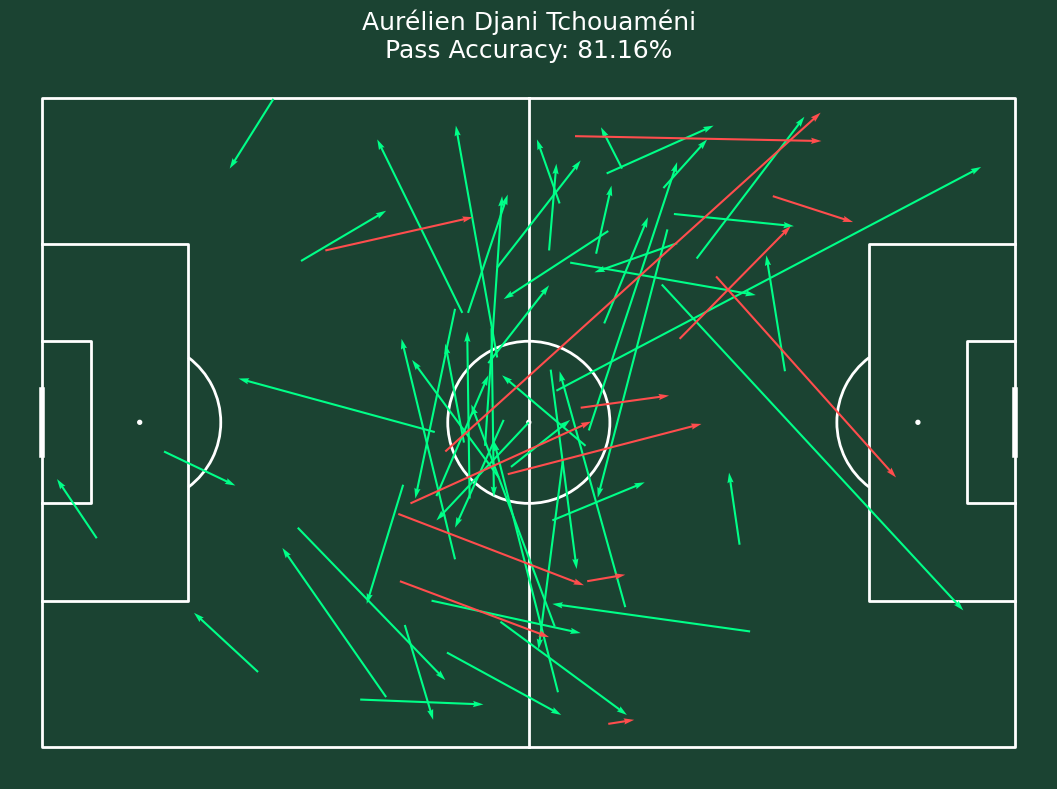

In [11]:
plot_player_passmap(
    events,
    'Aurélien Djani Tchouaméni'
)

'''🟢 Green arrows = successful passes
🔴 Red arrows = failed passes'''